In [ ]:
# =========================
# 1. SETUP E CONFIGURAÇÃO
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10,6)

In [5]:
def gerar_base_crm(n_leads=1000):

    origens = ["Instagram", "Google Ads", "Indicação", "Site", "OLX"]
    etapas_ordenadas = ["Lead", "Contato realizado", "Visita agendada", "Proposta enviada", "Fechado"]

    prob_fechamento = {
        "Instagram": 0.08,
        "Google Ads": 0.12,
        "Indicação": 0.25,
        "Site": 0.10,
        "OLX": 0.05
    }

    dados = []

    for i in range(n_leads):
        origem = random.choice(origens)
        data_entrada = datetime(2025,1,1) + timedelta(days=random.randint(0,180))
        valor_imovel = random.randint(300000,1500000)

        fechado = np.random.rand() < prob_fechamento[origem]

        if fechado:
            etapa = "Fechado"
            dias_funil = random.randint(30,120)
        else:
            etapa = random.choice(etapas_ordenadas[:-1])
            dias_funil = random.randint(1,60)

        data_ultima = data_entrada + timedelta(days=dias_funil)

        dados.append([
            i, origem, data_entrada, data_ultima,
            etapa, valor_imovel, fechado
        ])

    df = pd.DataFrame(dados, columns=[
        "lead_id","origem","data_entrada",
        "data_ultima_acao","etapa",
        "valor_imovel","fechado"
    ])

    df["dias_ciclo"] = (df["data_ultima_acao"] - df["data_entrada"]).dt.days

    return df

df = gerar_base_crm()
df.head()

,lead_id,origem,data_entrada,data_ultima_acao,etapa,valor_imovel,fechado,dias_ciclo
0,0,Site,2025-03-18,2025-04-25,Lead,1493970,False,38
1,1,Site,2025-01-29,2025-03-08,Contato realizado,1228287,False,38
2,2,OLX,2025-04-27,2025-06-15,Visita agendada,301038,False,49
3,3,Site,2025-06-03,2025-07-14,Proposta enviada,867789,False,41
4,4,Google Ads,2025-03-26,2025-04-28,Proposta enviada,1363870,False,33


In [7]:
# Receita apenas para vendas fechadas
df["receita"] = np.where(df["fechado"], df["valor_imovel"], 0)

# Receita por lead
df["receita_por_lead"] = df["receita"] / 1

In [8]:
etapas = ["Lead","Contato realizado","Visita agendada","Proposta enviada","Fechado"]

funil = df["etapa"].value_counts().reindex(etapas, fill_value=0)

funil

,count
etapa,
Lead,229
Contato realizado,216
Visita agendada,210
Proposta enviada,216
Fechado,129


In [9]:
taxa_conversao = df["fechado"].mean() * 100
taxa_conversao

np.float64(12.9)

In [10]:
resumo_canais = df.groupby("origem").agg(
    volume_leads = ("lead_id","count"),
    vendas = ("fechado","sum"),
    taxa_conversao = ("fechado","mean"),
    receita_total = ("receita","sum"),
    ticket_medio = ("valor_imovel","mean"),
    tempo_medio_ciclo = ("dias_ciclo","mean")
)

resumo_canais["taxa_conversao"] *= 100
resumo_canais.sort_values("receita_total", ascending=False)

,volume_leads,vendas,taxa_conversao,receita_total,ticket_medio,tempo_medio_ciclo
origem,,,,,,
Indicação,192,57,29.687500,51163702,905359.432292,44.005208
Google Ads,198,26,13.131313,24541284,901013.308081,35.686869
Instagram,197,17,8.629442,15712476,922141.365482,34.548223
Site,210,15,7.142857,14993531,907554.471429,33.528571
OLX,203,14,6.896552,11560860,893450.901478,34.167488


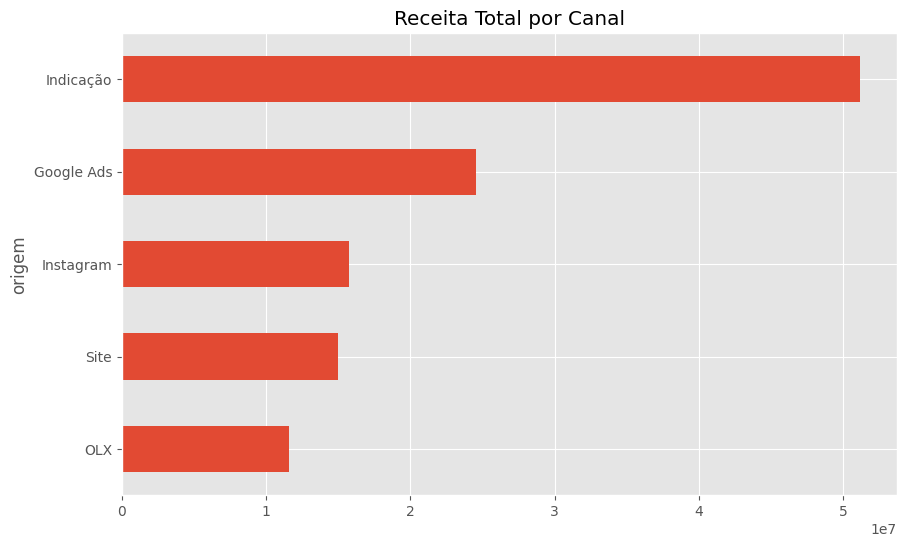

In [11]:
resumo_canais["receita_total"].sort_values().plot(kind="barh")
plt.title("Receita Total por Canal")
plt.show()

In [12]:
metricas = {
    "Total Leads": len(df),
    "Total Vendas": df["fechado"].sum(),
    "Taxa Conversão (%)": round(taxa_conversao,2),
    "Receita Total": df["receita"].sum(),
    "Ticket Médio": df[df["fechado"]]["valor_imovel"].mean(),
    "Tempo Médio de Fechamento": df[df["fechado"]]["dias_ciclo"].mean()
}

metricas

{'Total Leads': 1000,
 'Total Vendas': np.int64(129),
 'Taxa Conversão (%)': np.float64(12.9),
 'Receita Total': np.int64(117971853),
 'Ticket Médio': np.float64(914510.4883720931),
 'Tempo Médio de Fechamento': np.float64(75.4186046511628)}

In [14]:
melhor_canal = resumo_canais["receita_total"].idxmax()

dados_canal = resumo_canais.loc[melhor_canal]

leads_projetados = int(dados_canal["volume_leads"] * 1.2)
fechamentos_estimados = leads_projetados * (dados_canal["taxa_conversao"]/100)
receita_estimada = fechamentos_estimados * dados_canal["ticket_medio"]

receita_estimada

np.float64(61819073.73616536)